In [37]:
import graphix.command
from graphix.random_objects import Circuit, rand_circuit
from graphix.states import BasicStates
from graphix.sim.density_matrix import DensityMatrixBackend
from graphix.sim.statevec import StatevectorBackend, Statevec
from graphix.pauli import Pauli
from graphix.fundamentals import IXYZ
import stim
from graphix.channels import dephasing_channel
from graphix.noise_models import DepolarisingNoiseModel, NoiseModel, GlobalNoiseModel, NoiselessNoiseModel

from veriphix.client import Client, Secrets, CircuitUtils
import veriphix.client
import numpy as np
import random as rd
import seaborn as sns


Setting-up the instance

In [2]:
nqubits = 2
depth = 4
# Build the pattern
circuit = rand_circuit(nqubits, depth)
pattern = circuit.transpile().pattern 
pattern.minimize_space()
## Measure output nodes, to have classical output
classical_output = pattern.output_nodes
for onode in classical_output:
    pattern.add(graphix.command.M(node=onode))


In [26]:
client = Client(pattern=pattern, secrets=Secrets())
test_runs = client.create_test_runs()
print(len(test_runs))

3


In [48]:
threshold = 0.2
p_err = 0.6
fail_rates = []

for _ in range(100):
    # Trappified scheme parameters
    d = 0  # nr of computation rounds
    t = 100  # nr of test rounds
    N = d + t
    rounds = list(range(N))
    rd.shuffle(rounds)

    n_failed_trap_rounds = 0
    n_tolerated_failures = threshold*t

    backend = DensityMatrixBackend()
    noise_model = GlobalNoiseModel(prob=p_err, nodes=range(pattern.n_node))
    for i in rounds:
        if i < d:
            # Computation round
            pass
        else:
            # Test round
            run = rd.choice(test_runs)
            trap_outcomes = client.delegate_test_run(run=run, backend=backend, noise_model=noise_model)
            noise_model.refresh_randomness()

            # Record trap failure
            # A trap round fails if one of the single-qubit traps failed
            if sum(trap_outcomes) != 0:
                n_failed_trap_rounds += 1

    fail_rates.append(n_failed_trap_rounds/t)
    # print(n_failed_trap_rounds/t)
    # print(n_tolerated_failures/t)


expected = p_err/len(test_runs)


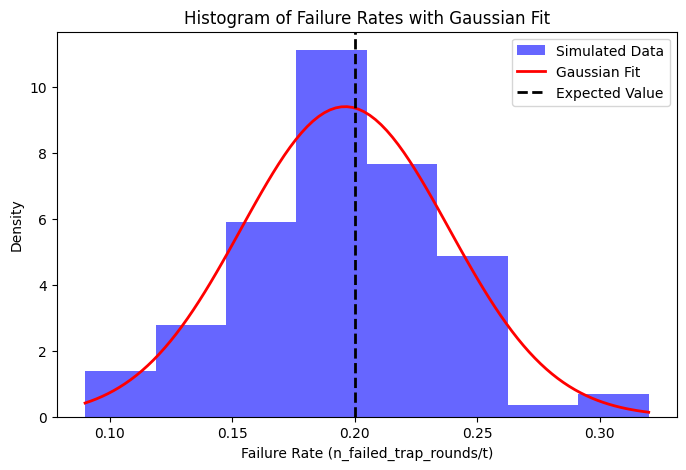

In [49]:
# Compute expected value
expected = p_err / len(test_runs)  # Assuming 10 single-qubit traps per test round

# Plot histogram
plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(fail_rates, bins=8, density=True, alpha=0.6, color='b', label='Simulated Data')

# Fit Gaussian curve
mu, std = norm.fit(fail_rates)
x = np.linspace(min(bins), max(bins), 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label='Gaussian Fit')

# Vertical line for expected value
plt.axvline(expected, color='k', linestyle='dashed', linewidth=2, label='Expected Value')

plt.xlabel('Failure Rate (n_failed_trap_rounds/t)')
plt.ylabel('Density')
plt.title('Histogram of Failure Rates with Gaussian Fit')
plt.legend()
plt.show()


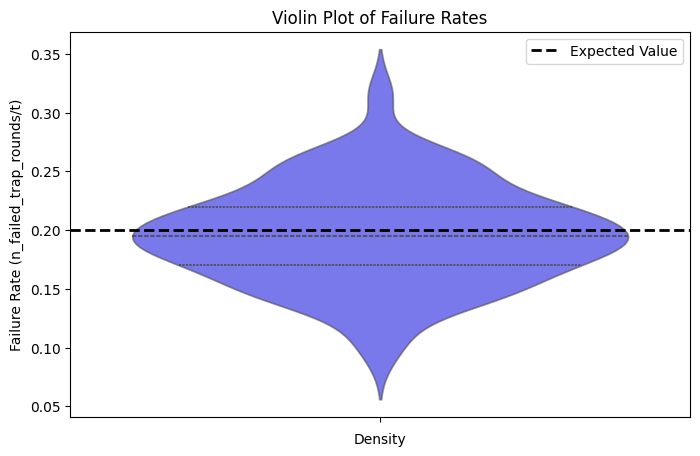

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute expected value
expected = p_err / len(test_runs)  # Assuming 10 single-qubit traps per test round

# Create the figure
plt.figure(figsize=(8, 5))

# Violin plot (oriented vertically)
sns.violinplot(data=fail_rates, color='b', inner="quartile", alpha=0.6)

# Horizontal line for expected value
plt.axhline(expected, color='k', linestyle='dashed', linewidth=2, label='Expected Value')

# Labels and title
plt.ylabel('Failure Rate (n_failed_trap_rounds/t)')  # Y-axis for failure rate
plt.xlabel('Density')  # X-axis for distribution
plt.title('Violin Plot of Failure Rates')

# Legend
plt.legend()
plt.show()


In [29]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
threshold = 0.2
p_err = 0.6
d = 50  # Computation rounds
t = 50  # Test rounds
N = d + t
n_tolerated_failures = threshold * t
num_experiments = 100

def run_experiment():
    rounds = list(range(N))
    rd.shuffle(rounds)
    n_failed_trap_rounds = 0
    
    for i in rounds:
        if i >= d:  # Test round
            trap_outcomes = client.delegate_test_run(run=run, backend=backend, noise_model=GlobalNoiseModel(prob=p_err, nodes=range(pattern.n_node)))
            if sum(trap_outcomes) != 0:
                n_failed_trap_rounds += 1
    
    return n_failed_trap_rounds / t

# Run the experiment multiple times
fail_rates = [run_experiment() for _ in range(num_experiments)]



UnboundLocalError: cannot access local variable 'n_failed_trap_rounds' where it is not associated with a value

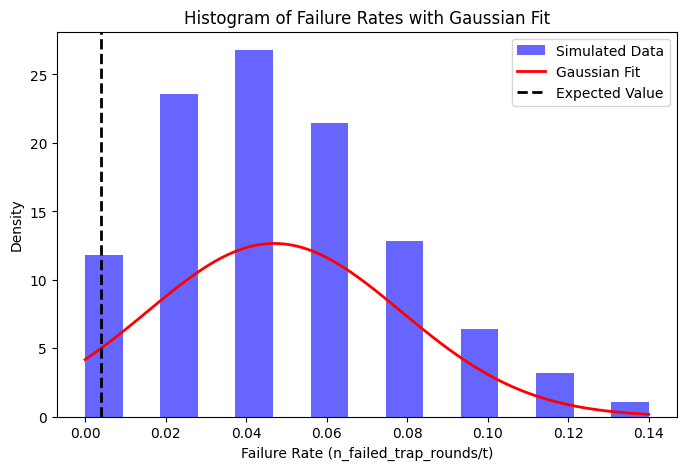

In [28]:
# Compute expected value
expected = p_err / len(test_runs) / t  # Assuming 10 single-qubit traps per test round

# Plot histogram
plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(fail_rates, bins=15, density=True, alpha=0.6, color='b', label='Simulated Data')

# Fit Gaussian curve
mu, std = norm.fit(fail_rates)
x = np.linspace(min(bins), max(bins), 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label='Gaussian Fit')

# Vertical line for expected value
plt.axvline(expected, color='k', linestyle='dashed', linewidth=2, label='Expected Value')

plt.xlabel('Failure Rate (n_failed_trap_rounds/t)')
plt.ylabel('Density')
plt.title('Histogram of Failure Rates with Gaussian Fit')
plt.legend()
plt.show()


Noise model:
- J'ai compris
- chaque round, soit on applique le bruit soit pas, selon la proba
- Si bruit, alors on choisit un qubit aléatoire et on confuse son résultat, et c'est un modèle de bruit fixe pour ce round

OU alors:
- On tire un qubit aléatoire à chaque round
- Le modèle de bruit devient: pour ce qubit, flip avec probabilité $p$
- dephasing_channel dans `KrausChannel`



Pour une instance de QCircuit donnée
- on décide si on accepte ou pas le calcul selon le nombre de failed test rounds, on regarde si c'erst en dessous du theshold

Ensuite, on regarde la distribution sur toutes les instances, et on regarde la proportion de failed trap rounds. En principe, ça doit converger autour de $p/k$. Mais certaines instances en auront un peu au-dessus, un peu en dessous, donc en gros on aura une Gaussienne centrée autour de $p/k$. Et il faut plotter un violon chart, avec un point idéal autour de $p/k$, et un point expérimental qui sera en gros la moyenne sur toutes les instances.



Ensuite il faut générer le plot stylé.